In [2]:
pip install -U scikit-learn

data : band_powers.npy & coords.npy

In [9]:
# ----- cell 1 -----
# load the data
# define function polynomial intepolation
# define yuanting():invoke function interpolate_chebyshev and timekeeping
# 10-fold
# visualization as table
# ---------------------
#import your packages
import os
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from numpy.polynomial.chebyshev import chebvander
import pandas as pd

#the idea will be that everyone is importing the same functions from a python file
#for now this is commented out as you develop your own functions.
#from metrics import calculate_metrics
#from interpolation_functions import your function


#load in the dataset
#Loading the coordinates from the .npy file with shape [1772, 3]
#1772 xyz coordinates
file_path = '/content'

coords_path = os.path.join(file_path, 'coords.npy')
coords = np.load(coords_path)

#load in band power dataset
band_powers_path = os.path.join(file_path, 'band_powers.npy')
band_powers = np.load(band_powers_path, allow_pickle=True).item()

band = 'Delta' # we can change the band frequency
band_values = np.array(band_powers[band])


def yuanting(coords, values, new_coords, degree=3, alpha=1.0, timing=False):
    """
    Wrapper function to interpolate using Chebyshev polynomial and optionally return time.
    """
    start_time = time.time()
    predicted_values = interpolate_chebyshev(coords, values, new_coords, degree=degree, alpha=alpha)
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values


def interpolate_chebyshev(coords, values, new_coords, degree=3, alpha=1.0):
    """
    Performs Chebyshev polynomial interpolation with Ridge regression.
    """
    X_scaled = 2 * (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0)) - 1
    new_scaled = 2 * (new_coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0)) - 1

    features = [chebvander(X_scaled[:, i], degree) for i in range(coords.shape[1])]
    combined = np.einsum('ij,ik,il->ijkl', *features).reshape(coords.shape[0], -1)

    new_features = [chebvander(new_scaled[:, i], degree) for i in range(coords.shape[1])]
    new_combined = np.einsum('ij,ik,il->ijkl', *new_features).reshape(new_coords.shape[0], -1)

    model = Ridge(alpha=alpha)
    model.fit(combined, values)
    preds = model.predict(new_combined)
    return preds


def calculate_metrics(pred_values, test_values, metrics=None):
    """
    Computes error metrics to evaluate interpolation performance.
    """
    scores = {
        "mse": mean_squared_error(test_values, pred_values),
        "mae": mean_absolute_error(test_values, pred_values),
        "rmse": mean_squared_error(test_values, pred_values),
        "r2": r2_score(test_values, pred_values)
    }
    return scores


# Define metrics to evaluate interpolation
metrics = ['mse', 'mae', 'rmse', 'r2']

# Initialize arrays to store results
num_folds = 10
degrees = list(range(1, 21))  # polynomial degree range from 1 to 20

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

# Initialize result containers
results = {metric: pd.DataFrame(index=range(num_folds), columns=degrees) for metric in metrics}
timings = np.zeros((num_folds, len(degrees)))

# Perform k-fold cross-validation across different polynomial degrees
for j, degree in enumerate(degrees):
    for i, (train_index, test_index) in enumerate(kf.split(coords)):
        train_values, train_coords = band_values[train_index], coords[train_index]
        test_values, test_coords = band_values[test_index], coords[test_index]

        # Run interpolation and measure execution time
        pred_values, timings[i, j] = yuanting(train_coords, train_values, test_coords, degree=degree, timing=True)

        # Compute evaluation metrics
        scores = calculate_metrics(pred_values, test_values)
        for metric in metrics:
            results[metric].loc[i, degree] = scores[metric]

# Convert results to numeric
for metric in results:
    results[metric] = results[metric].astype(float)

# Visualization: Plot stored metrics (y-axis) against interpolation setups (x-axis, e.g., polynomial degree)
# Add appropriate visualization code here if needed
print("MSE Table:")
display(results['mse'])

print("MAE Table:")
display(results['mae'])

print("RMSE Table:")
display(results['rmse'])

print("R2 Table:")
display(results['r2'])

#for the project, each team member should have for 2 sets of plots.
#1 for their internal callibration experiments to figure out the best version of their model
#2 comparing the different models that you've all implemented


MSE Table:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.004572,0.004020,0.003903,0.003568,0.003431,0.003262,0.003884,0.003986,0.003567,0.004984,0.006480,0.008159,0.009561,0.011643,0.018232,0.015232,0.016538,0.019195,0.023851,0.023749
1,0.004905,0.004396,0.004215,0.003769,0.003613,0.003697,0.004031,0.004588,0.004921,0.004025,0.004563,0.005755,0.007498,0.014823,0.015904,0.015906,0.020141,0.026351,0.028930,0.032156
2,0.004521,0.004297,0.004159,0.003439,0.003348,0.003376,0.003366,0.003328,0.003393,0.003658,0.004952,0.005397,0.006689,0.008492,0.008914,0.011232,0.015165,0.023591,0.029885,0.029975
3,0.003906,0.003477,0.003473,0.003075,0.002915,0.003023,0.003042,0.003062,0.003266,0.003737,0.004398,0.005537,0.006332,0.006348,0.007213,0.008111,0.017274,0.015671,0.022880,0.022142
4,0.004164,0.003964,0.003745,0.003485,0.003628,0.004158,0.004573,0.009988,0.006407,0.036105,0.036248,0.012318,0.111215,0.626607,0.020493,1.187105,1.310066,8.340017,2.994562,3.003493
5,0.004176,0.003668,0.003563,0.003317,0.003483,0.003404,0.003981,0.003314,0.004496,0.005739,0.010256,0.005164,0.006750,0.007428,0.009147,0.018007,0.015283,0.018071,0.020517,0.028339
6,0.004167,0.003709,0.003689,0.003405,0.003299,0.003224,0.003465,0.003358,0.005926,0.004677,0.005791,0.021915,0.099183,0.605260,0.647936,2.919037,1.583199,5.431392,14.529932,11.071502
7,0.004284,0.004095,0.004039,0.004178,0.004381,0.003986,0.003747,0.003757,0.005159,0.004884,0.007505,0.006389,0.006497,0.007547,0.012502,0.011937,0.014574,0.015431,0.021690,0.027021
8,0.003868,0.003807,0.003875,0.003872,0.004366,0.004565,0.005401,0.006616,0.007297,0.006212,0.015586,0.018757,0.032394,0.027703,0.221803,0.193538,0.089960,0.056074,0.613681,1.446126
9,0.004197,0.003762,0.003977,0.003564,0.003582,0.003506,0.003530,0.003495,0.004160,0.003897,0.004704,0.008289,0.008628,0.010469,0.010901,0.011947,0.015260,0.019894,0.024031,0.023780


MAE Table:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.055462,0.052168,0.051705,0.049605,0.048332,0.047252,0.051884,0.050128,0.049251,0.051529,0.056661,0.062613,0.070795,0.075168,0.088046,0.087031,0.095775,0.098843,0.107114,0.108158
1,0.057378,0.053469,0.052890,0.049551,0.048614,0.048542,0.051171,0.053152,0.054811,0.049463,0.052516,0.055333,0.062043,0.074040,0.078885,0.086750,0.098938,0.112447,0.115939,0.128807
2,0.055886,0.053389,0.053728,0.048544,0.047617,0.047481,0.047190,0.045597,0.046734,0.048502,0.054067,0.052992,0.058487,0.063239,0.065926,0.073246,0.086747,0.107430,0.120826,0.124590
3,0.051177,0.048431,0.048236,0.045292,0.044702,0.045524,0.045800,0.045535,0.046349,0.047254,0.051942,0.057362,0.058967,0.060768,0.062049,0.067176,0.088878,0.092033,0.107179,0.109637
4,0.050949,0.049750,0.048264,0.047225,0.047485,0.047408,0.049799,0.055509,0.054060,0.065490,0.067471,0.061492,0.087762,0.129512,0.086288,0.171579,0.183216,0.326190,0.238893,0.237937
5,0.053931,0.049800,0.049408,0.047652,0.047645,0.047475,0.048204,0.045341,0.049845,0.054927,0.059624,0.054856,0.057519,0.061505,0.067522,0.081608,0.084276,0.090670,0.100746,0.119121
6,0.053145,0.048456,0.047569,0.046125,0.045736,0.045017,0.046709,0.046440,0.051168,0.049620,0.054133,0.066241,0.079689,0.128153,0.143170,0.218881,0.182396,0.267134,0.403216,0.373174
7,0.052512,0.050254,0.050542,0.050305,0.050484,0.049790,0.048026,0.047048,0.051886,0.052039,0.058176,0.056566,0.060288,0.067417,0.079691,0.080616,0.086115,0.090659,0.104633,0.120659
8,0.051915,0.049846,0.050773,0.049639,0.051418,0.051481,0.055321,0.058102,0.057220,0.055330,0.069054,0.072437,0.087377,0.084386,0.125726,0.150041,0.134065,0.127932,0.218269,0.254371
9,0.053044,0.050364,0.051403,0.048070,0.047392,0.046477,0.046598,0.045500,0.049758,0.048099,0.052982,0.061176,0.064435,0.069720,0.073641,0.077819,0.086129,0.093695,0.101006,0.097462


RMSE Table:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.004572,0.004020,0.003903,0.003568,0.003431,0.003262,0.003884,0.003986,0.003567,0.004984,0.006480,0.008159,0.009561,0.011643,0.018232,0.015232,0.016538,0.019195,0.023851,0.023749
1,0.004905,0.004396,0.004215,0.003769,0.003613,0.003697,0.004031,0.004588,0.004921,0.004025,0.004563,0.005755,0.007498,0.014823,0.015904,0.015906,0.020141,0.026351,0.028930,0.032156
2,0.004521,0.004297,0.004159,0.003439,0.003348,0.003376,0.003366,0.003328,0.003393,0.003658,0.004952,0.005397,0.006689,0.008492,0.008914,0.011232,0.015165,0.023591,0.029885,0.029975
3,0.003906,0.003477,0.003473,0.003075,0.002915,0.003023,0.003042,0.003062,0.003266,0.003737,0.004398,0.005537,0.006332,0.006348,0.007213,0.008111,0.017274,0.015671,0.022880,0.022142
4,0.004164,0.003964,0.003745,0.003485,0.003628,0.004158,0.004573,0.009988,0.006407,0.036105,0.036248,0.012318,0.111215,0.626607,0.020493,1.187105,1.310066,8.340017,2.994562,3.003493
5,0.004176,0.003668,0.003563,0.003317,0.003483,0.003404,0.003981,0.003314,0.004496,0.005739,0.010256,0.005164,0.006750,0.007428,0.009147,0.018007,0.015283,0.018071,0.020517,0.028339
6,0.004167,0.003709,0.003689,0.003405,0.003299,0.003224,0.003465,0.003358,0.005926,0.004677,0.005791,0.021915,0.099183,0.605260,0.647936,2.919037,1.583199,5.431392,14.529932,11.071502
7,0.004284,0.004095,0.004039,0.004178,0.004381,0.003986,0.003747,0.003757,0.005159,0.004884,0.007505,0.006389,0.006497,0.007547,0.012502,0.011937,0.014574,0.015431,0.021690,0.027021
8,0.003868,0.003807,0.003875,0.003872,0.004366,0.004565,0.005401,0.006616,0.007297,0.006212,0.015586,0.018757,0.032394,0.027703,0.221803,0.193538,0.089960,0.056074,0.613681,1.446126
9,0.004197,0.003762,0.003977,0.003564,0.003582,0.003506,0.003530,0.003495,0.004160,0.003897,0.004704,0.008289,0.008628,0.010469,0.010901,0.011947,0.015260,0.019894,0.024031,0.023780


R2 Table:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.023641,0.141475,0.166375,0.237933,0.267239,0.303358,0.170557,0.148660,0.238253,-0.064377,-0.383981,-0.742413,-1.041934,-1.486614,-2.893659,-2.253112,-2.531937,-3.099356,-4.093834,-4.071871
1,0.078858,0.174393,0.208359,0.292148,0.321418,0.305582,0.242857,0.138268,0.075777,0.244043,0.142996,-0.080898,-0.408225,-1.783952,-1.986879,-1.987272,-2.782796,-3.949107,-4.433385,-5.039323
2,0.149489,0.191752,0.217620,0.353185,0.370288,0.364889,0.366782,0.373979,0.361790,0.311867,0.068415,-0.015317,-0.258192,-0.597374,-0.676726,-1.112792,-1.852581,-3.437607,-4.621623,-4.638478
3,0.071668,0.173579,0.174588,0.269153,0.307126,0.281559,0.276942,0.272314,0.223615,0.111847,-0.045304,-0.316171,-0.505103,-0.508801,-0.714478,-0.927888,-3.105828,-2.724739,-4.438314,-4.262879
4,0.119811,0.162133,0.208372,0.263332,0.233162,0.121115,0.033323,-1.111087,-0.354258,-6.631404,-6.661707,-1.603634,-22.507219,-131.443859,-3.331602,-249.914502,-275.904265,-1761.801519,-631.950513,-633.838320
5,0.145013,0.249154,0.270591,0.320943,0.286871,0.303044,0.184984,0.321439,0.079546,-0.174901,-1.099659,-0.057144,-0.381884,-0.520784,-0.872657,-2.686545,-2.128837,-2.699489,-3.200350,-4.801658
6,0.179940,0.270034,0.274021,0.329962,0.350757,0.365529,0.318054,0.339092,-0.166268,0.079474,-0.139657,-3.313079,-18.519702,-118.118679,-126.517467,-573.482970,-310.582550,-1067.928697,-2858.572894,-2177.934233
7,0.163023,0.199920,0.211013,0.183735,0.144140,0.221339,0.268016,0.266108,-0.007910,0.045799,-0.466245,-0.248146,-0.269294,-0.474424,-1.442454,-1.332063,-1.847238,-2.014701,-3.237443,-4.278958
8,0.020257,0.035876,0.018540,0.019356,-0.105849,-0.156198,-0.367923,-0.675732,-0.847969,-0.573297,-2.947380,-3.750543,-7.204341,-6.016216,-55.175166,-48.016476,-21.783694,-13.201641,-154.424417,-365.254397
9,0.103648,0.196415,0.150597,0.238743,0.235023,0.251106,0.246002,0.253569,0.111495,0.167590,-0.004760,-0.770472,-0.842874,-1.235951,-1.328174,-1.551544,-2.259300,-3.249051,-4.132597,-4.078869


Average Scores by Degree (Chebyshev):

MSE:
1     0.004276
2     0.003919
3     0.003864
4     0.003567
5     0.003605
6     0.003620
7     0.003902
8     0.004549
9     0.004859
10    0.007792
11    0.010048
12    0.009768
13    0.029475
14    0.132632
15    0.097304
16    0.439205
17    0.309746
18    1.396569
19    1.830996
20    1.570828
dtype: float64

MAE:
1     0.053540
2     0.050593
3     0.050452
4     0.048201
5     0.047942
6     0.047645
7     0.049070
8     0.049235
9     0.051108
10    0.052225
11    0.057663
12    0.060107
13    0.068736
14    0.081391
15    0.087094
16    0.109475
17    0.112654
18    0.140703
19    0.161782
20    0.167392
dtype: float64

RMSE:
1     0.004276
2     0.003919
3     0.003864
4     0.003567
5     0.003605
6     0.003620
7     0.003902
8     0.004549
9     0.004859
10    0.007792
11    0.010048
12    0.009768
13    0.029475
14    0.132632
15    0.097304
16    0.439205
17    0.309746
18    1.396569
19    1.830996
20    1.570828
dtype: float6

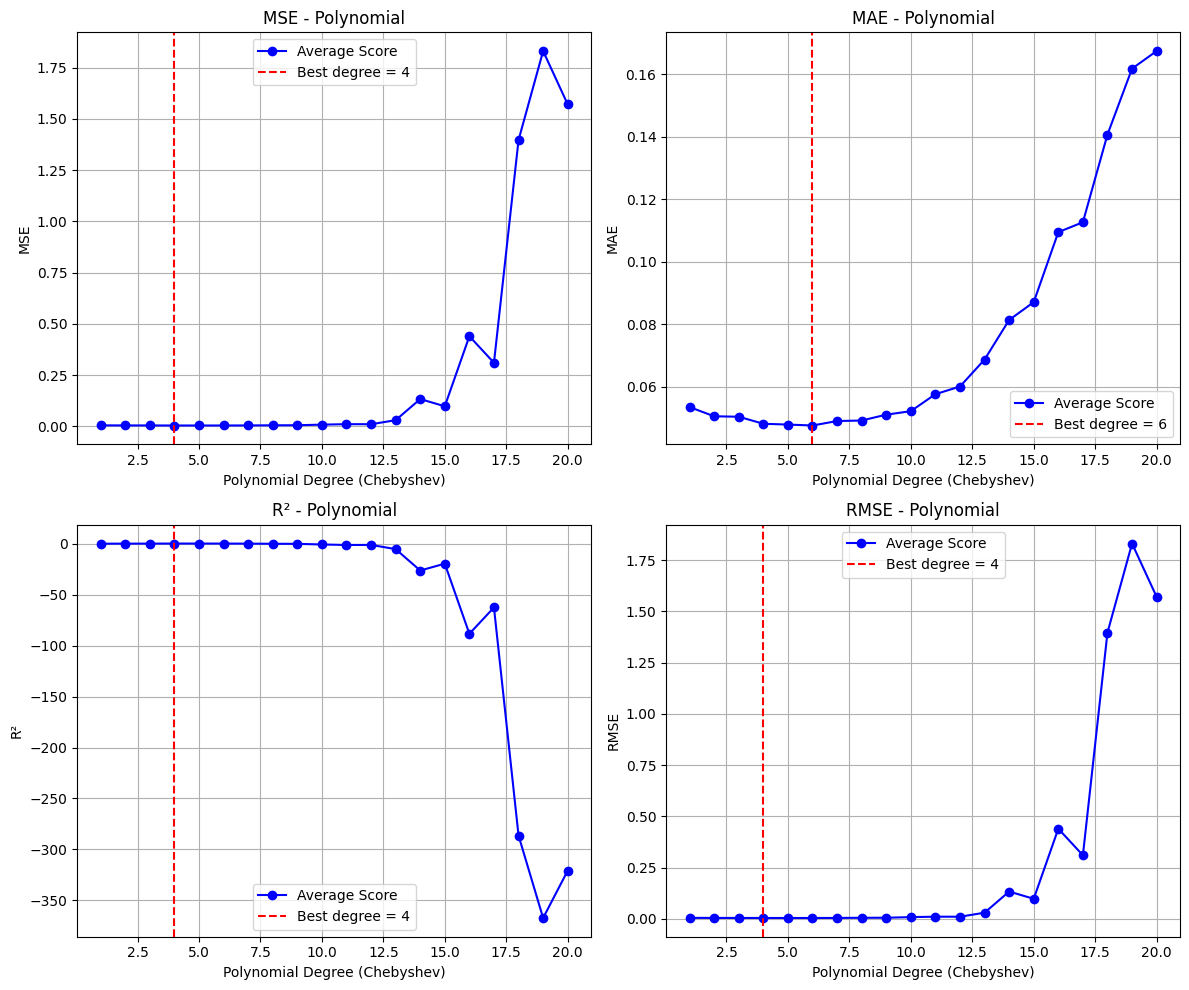

In [9]:
# ----- cell 2 -----
# calculate the average of each degree
# line chart
# ---------------------
# Compute average scores across folds for each degree
mean_metrics = {metric: results[metric].mean(axis=0) for metric in results}

# Print average values for each degree
print("Average Scores by Degree (Chebyshev):")
for metric in mean_metrics:
    print(f"\n{metric.upper()}:")
    print(mean_metrics[metric])

# Identify best degree for each metric
best_degrees = {
    "mse": mean_metrics["mse"].idxmin(),
    "mae": mean_metrics["mae"].idxmin(),
    "rmse": mean_metrics["rmse"].idxmin(),
    "r2": mean_metrics["r2"].idxmax()
}

# Plotting line plots with best degree marked
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()
titles = ["MSE - Polynomial", "MAE - Polynomial", "R² - Polynomial", "RMSE - Polynomial"]
ylabels = ["MSE", "MAE", "R²", "RMSE"]
metrics_list = ["mse", "mae", "r2", "rmse"]

for i, metric in enumerate(metrics_list):
    degrees = mean_metrics[metric].index
    values = mean_metrics[metric].values
    axs[i].plot(degrees, values, marker='o', color='blue', label='Average Score')
    axs[i].axvline(best_degrees[metric], color="red", linestyle="--", label=f"Best degree = {best_degrees[metric]}")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Polynomial Degree (Chebyshev)")
    axs[i].set_ylabel(ylabels[i])
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


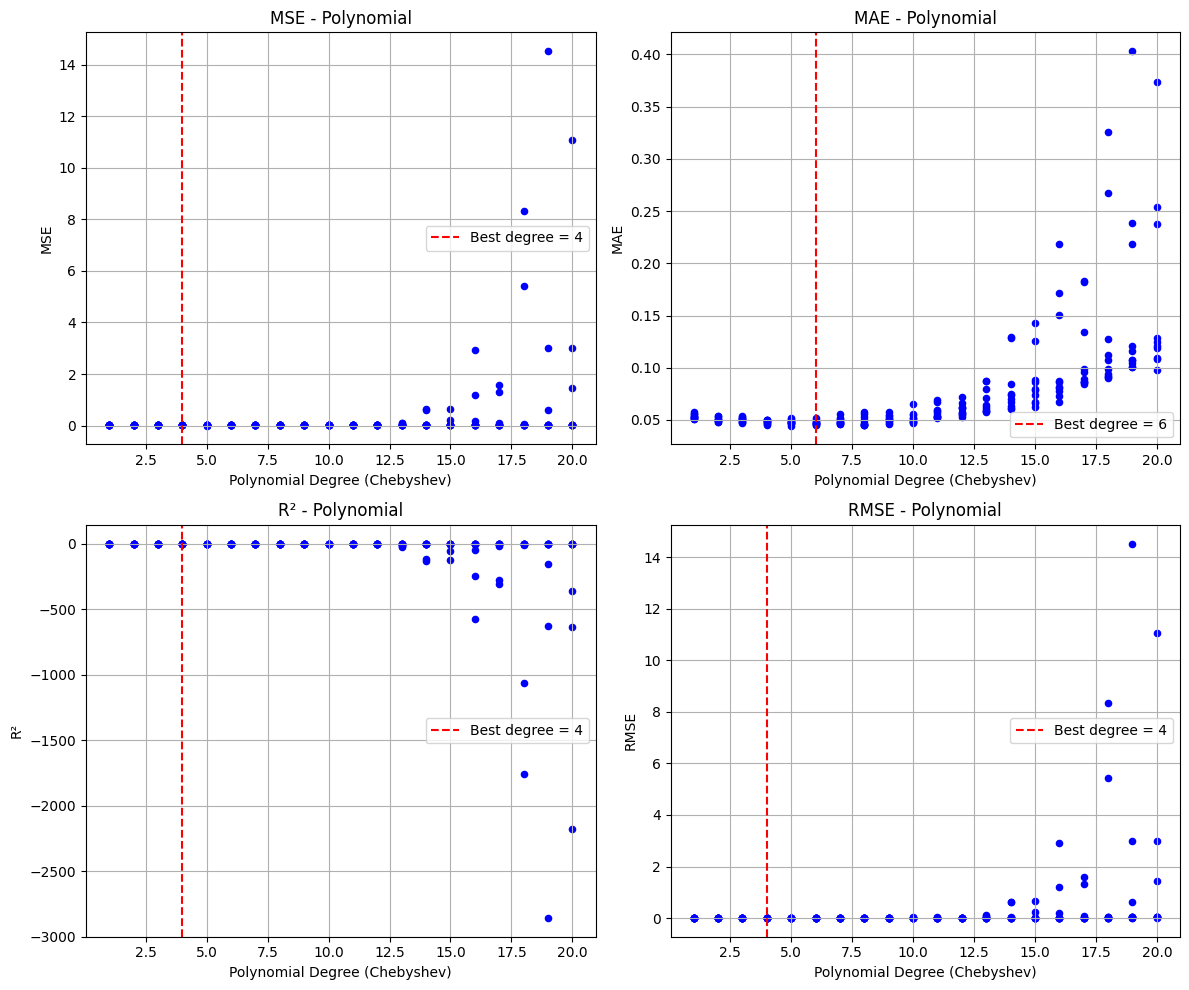

In [4]:
# ----- cell 3 -----
# show the scatter diagram which can show each fold
# show the best degree according to different evaluations atrand
# ---------------------
import matplotlib.pyplot as plt
# Plotting all folds' scores (scatter points per fold and degree)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

titles = ["MSE - Polynomial", "MAE - Polynomial", "R² - Polynomial", "RMSE - Polynomial"]
ylabels = ["MSE", "MAE", "R²", "RMSE"]
metrics_list = ["mse", "mae", "r2", "rmse"]

# Compute average values to find best degree per metric
mean_metrics = {metric: results[metric].mean(axis=0) for metric in results}
best_degrees = {
    "mse": mean_metrics["mse"].idxmin(),
    "mae": mean_metrics["mae"].idxmin(),
    "rmse": mean_metrics["rmse"].idxmin(),
    "r2": mean_metrics["r2"].idxmax()
}

# Plot each fold’s score as a dot
for i, metric in enumerate(metrics_list):
    for degree in results[metric].columns:
        axs[i].scatter([degree]*results[metric].shape[0], results[metric][degree],
                       color="blue", s=20)
    axs[i].axvline(best_degrees[metric], color="red", linestyle="--",
                   label=f"Best degree = {best_degrees[metric]}")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Polynomial Degree (Chebyshev)")
    axs[i].set_ylabel(ylabels[i])
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [10]:
# ----- cell 4 -----
# t-test: degree 2-6
# ---------------------
from scipy.stats import ttest_rel
import itertools

# Define which degrees to compare
target_degrees = list(range(2, 7))  # degrees 2 to 6
metrics_to_test = ["mse", "mae", "rmse", "r2"]

# Perform t-tests and collect results per metric
ttest_tables = {}

for metric in metrics_to_test:
    subset = results[metric].loc[:, target_degrees]
    degree_pairs = list(itertools.combinations(subset.columns, 2))
    ttest_results = []

    for d1, d2 in degree_pairs:
        t_stat, p_val = ttest_rel(subset[d1], subset[d2])
        ttest_results.append((d1, d2, p_val))

    df = pd.DataFrame(ttest_results, columns=["Degree 1", "Degree 2", "p-value"])
    df_sorted = df.sort_values("p-value")
    ttest_tables[metric] = df_sorted

# Display all four t-test tables
for metric in metrics_to_test:
    print(f"\nPairwise t-test on {metric.upper()} (degree 2–6):")
    display(ttest_tables[metric])



Pairwise t-test on MSE (degree 2–6):


,Degree 1,Degree 2,p-value
4,3,4,0.003360
1,2,4,0.003843
2,2,5,0.059855
5,3,5,0.081309
3,2,6,0.088800
6,3,6,0.137793
0,2,3,0.202176
7,4,5,0.591882
8,4,6,0.641759
9,5,6,0.844995



Pairwise t-test on MAE (degree 2–6):


,Degree 1,Degree 2,p-value
1,2,4,0.000642
4,3,4,0.000869
3,2,6,0.002519
6,3,6,0.002765
2,2,5,0.004225
5,3,5,0.004493
9,5,6,0.129188
8,4,6,0.164353
7,4,5,0.375665
0,2,3,0.588236



Pairwise t-test on RMSE (degree 2–6):


,Degree 1,Degree 2,p-value
4,3,4,0.003360
1,2,4,0.003843
2,2,5,0.059855
5,3,5,0.081309
3,2,6,0.088800
6,3,6,0.137793
0,2,3,0.202176
7,4,5,0.591882
8,4,6,0.641759
9,5,6,0.844995



Pairwise t-test on R2 (degree 2–6):


,Degree 1,Degree 2,p-value
4,3,4,0.002605
1,2,4,0.003136
2,2,5,0.079037
5,3,5,0.104085
3,2,6,0.134747
6,3,6,0.195370
0,2,3,0.245489
7,4,5,0.547273
8,4,6,0.572346
9,5,6,0.770629


In [28]:
# ----- Cell 5 -----
# Investigate the effect of different alpha values (regularization strength) on interpolation
# --------------------------------------------------------

alpha_values = [0.01, 0.1, 1.0, 10, 100]  # You can expand this list
fixed_degree = 4  # Or set this to your selected best degree
num_folds = 10

# Containers to hold results for each metric and alpha
alpha_results = {metric: pd.DataFrame(index=range(num_folds), columns=alpha_values) for metric in metrics}

kf = KFold(n_splits=num_folds, shuffle=True, random_state=42)

for alpha in alpha_values:
    for i, (train_index, test_index) in enumerate(kf.split(coords)):
        train_coords, test_coords = coords[train_index], coords[test_index]
        train_values, test_values = band_values[train_index], band_values[test_index]

        pred_values = yuanting(train_coords, train_values, test_coords, degree=fixed_degree, alpha=alpha)

        scores = calculate_metrics(pred_values, test_values)
        for metric in metrics:
            alpha_results[metric].loc[i, alpha] = scores[metric]

# Convert result values to float
for metric in alpha_results:
    alpha_results[metric] = alpha_results[metric].astype(float)

# === Display results as tables ===
print(f"Evaluation across alpha values at degree={fixed_degree}\n")

print("MSE Table:")
display(alpha_results["mse"])

print("MAE Table:")
display(alpha_results["mae"])

print("RMSE Table:")
display(alpha_results["rmse"])

print("R2 Table:")
display(alpha_results["r2"])


Evaluation across alpha values at degree=4

MSE Table:


,0.01,0.10,1.00,10.00,100.00
0,0.392187,0.385748,0.380972,0.381526,0.385051
1,0.516459,0.511781,0.502909,0.498292,0.519605
2,0.522629,0.523335,0.523704,0.517304,0.518433
3,0.487989,0.483831,0.479375,0.479061,0.494970
4,0.595146,0.586849,0.582959,0.577416,0.585654
5,0.468912,0.466210,0.458967,0.446997,0.440243
6,0.393006,0.388444,0.390550,0.391751,0.413886
7,0.498454,0.491521,0.479092,0.474436,0.499556
8,0.409381,0.400132,0.391521,0.389846,0.404885
9,0.546879,0.547986,0.550819,0.555580,0.565354


MAE Table:


,0.01,0.10,1.00,10.00,100.00
0,0.491123,0.486595,0.480487,0.477932,0.484219
1,0.563431,0.560686,0.551785,0.549417,0.576183
2,0.554625,0.554770,0.553883,0.554300,0.565842
3,0.551036,0.545582,0.542795,0.537150,0.546444
4,0.558276,0.551532,0.549015,0.548639,0.559130
5,0.536875,0.536034,0.533778,0.529882,0.530703
6,0.497968,0.498317,0.500739,0.501615,0.507230
7,0.582005,0.580655,0.573217,0.574156,0.597992
8,0.479226,0.475738,0.472530,0.470798,0.481815
9,0.562086,0.563532,0.565044,0.568960,0.572547


RMSE Table:


,0.01,0.10,1.00,10.00,100.00
0,0.392187,0.385748,0.380972,0.381526,0.385051
1,0.516459,0.511781,0.502909,0.498292,0.519605
2,0.522629,0.523335,0.523704,0.517304,0.518433
3,0.487989,0.483831,0.479375,0.479061,0.494970
4,0.595146,0.586849,0.582959,0.577416,0.585654
5,0.468912,0.466210,0.458967,0.446997,0.440243
6,0.393006,0.388444,0.390550,0.391751,0.413886
7,0.498454,0.491521,0.479092,0.474436,0.499556
8,0.409381,0.400132,0.391521,0.389846,0.404885
9,0.546879,0.547986,0.550819,0.555580,0.565354


R2 Table:


,0.01,0.10,1.00,10.00,100.00
0,0.523349,0.531175,0.536979,0.536306,0.532023
1,0.541123,0.545280,0.553162,0.557264,0.538328
2,0.552989,0.552384,0.552069,0.557543,0.556578
3,0.472907,0.477398,0.482212,0.482551,0.465367
4,0.405453,0.413742,0.417628,0.423166,0.414936
5,0.463985,0.467074,0.475354,0.489037,0.496757
6,0.592442,0.597173,0.594989,0.593744,0.570789
7,0.423607,0.431624,0.445997,0.451381,0.422333
8,0.632423,0.640728,0.648460,0.649963,0.636460
9,0.485175,0.484133,0.481465,0.476984,0.467783


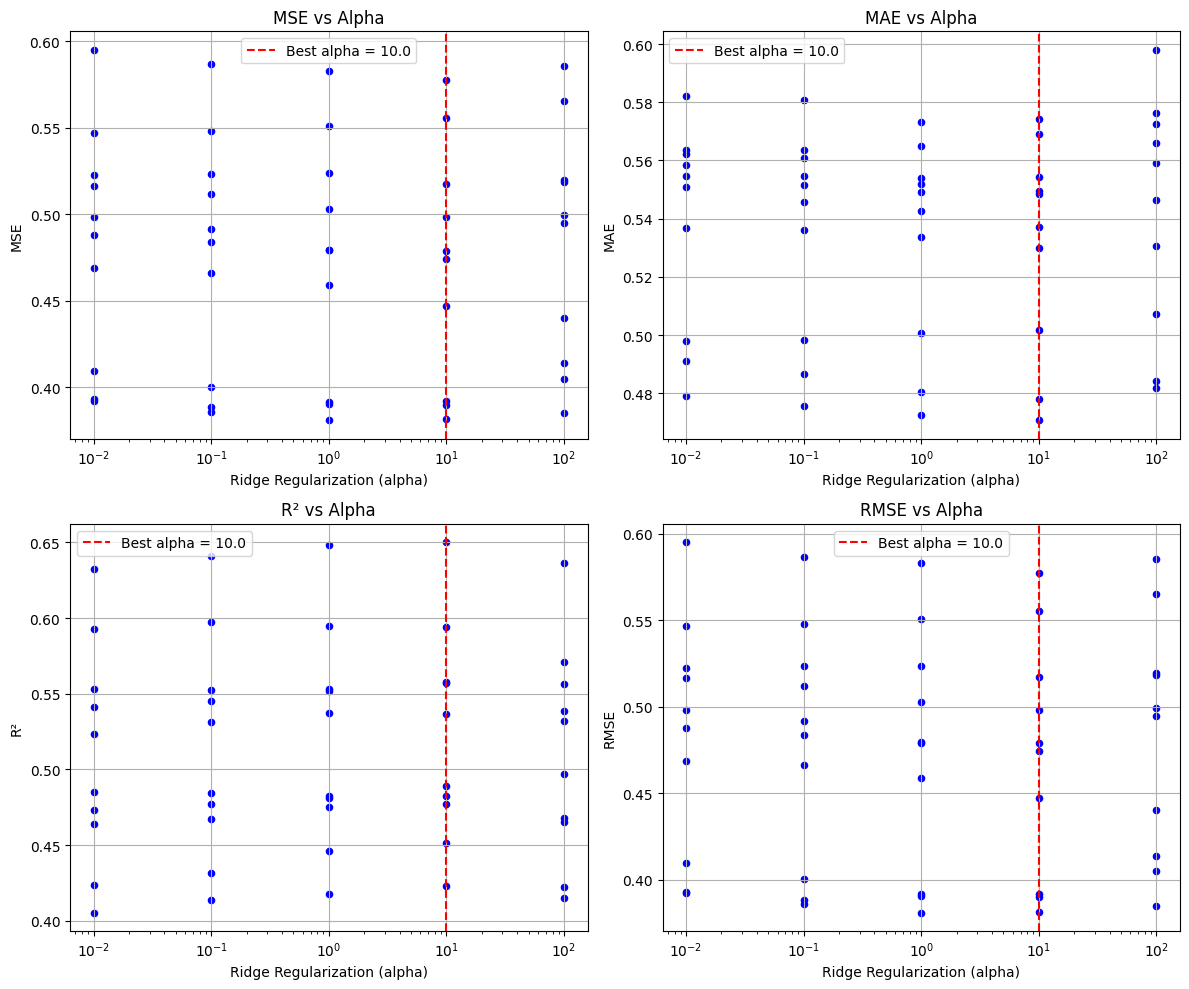

In [29]:
# ----- Cell 6 -----
# Visualize the effect of different alpha values on metrics (scatter per fold)
# --------------------------------------------------------

fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

titles = ["MSE vs Alpha", "MAE vs Alpha", "R² vs Alpha", "RMSE vs Alpha"]
ylabels = ["MSE", "MAE", "R²", "RMSE"]
metrics_list = ["mse", "mae", "r2", "rmse"]

# Compute average values to find best alpha per metric
mean_metrics_alpha = {metric: alpha_results[metric].mean(axis=0) for metric in alpha_results}
best_alphas = {
    "mse": mean_metrics_alpha["mse"].idxmin(),
    "mae": mean_metrics_alpha["mae"].idxmin(),
    "rmse": mean_metrics_alpha["rmse"].idxmin(),
    "r2": mean_metrics_alpha["r2"].idxmax()
}

# Plot per fold scatter and best alpha
for i, metric in enumerate(metrics_list):
    for alpha in alpha_results[metric].columns:
        axs[i].scatter([alpha]*alpha_results[metric].shape[0], alpha_results[metric][alpha],
                       color="blue", s=20)
    axs[i].axvline(best_alphas[metric], color="red", linestyle="--",
                   label=f"Best alpha = {best_alphas[metric]}")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Ridge Regularization (alpha)")
    axs[i].set_ylabel(ylabels[i])
    axs[i].set_xscale("log")  # Optional: log scale for better spacing
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


Performance at degree = 4 with alpha = 10
MSE: 0.43780
MAE: 0.51102
RMSE: 0.43780
R2: 0.56144


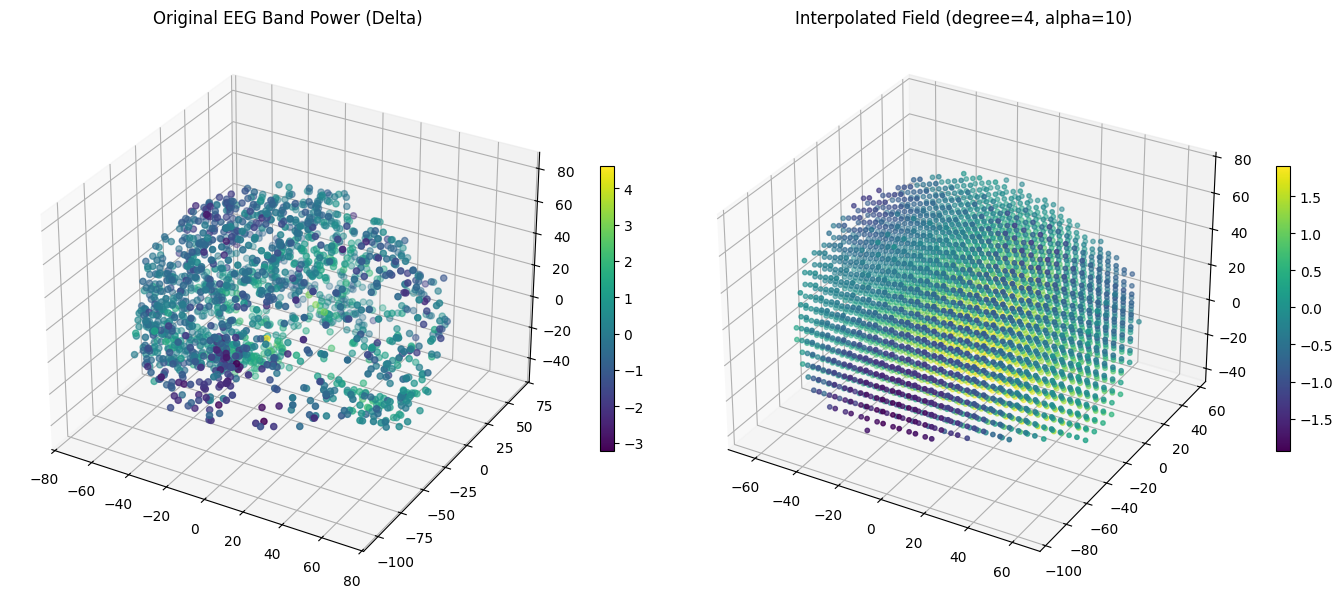

In [30]:
# ----- Cell 7 -----
# Show 3D visualization + Print metrics for best degree (alpha=10)
# ---------------------
from mpl_toolkits.mplot3d import Axes3
from matplotlib import cm
from scipy.spatial import Delaunay

# Select the best degree and alpha to visualize
best_degree = 4
best_alpha = 10

# Use all points to train
train_coords = coords
train_values = band_values

# Generate a dense 3D grid covering the whole bounding box
grid_size = 20
x = np.linspace(coords[:, 0].min(), coords[:, 0].max(), grid_size)
y = np.linspace(coords[:, 1].min(), coords[:, 1].max(), grid_size)
z = np.linspace(coords[:, 2].min(), coords[:, 2].max(), grid_size)
xx, yy, zz = np.meshgrid(x, y, z)
grid_coords = np.vstack([xx.ravel(), yy.ravel(), zz.ravel()]).T

# Only keep points inside the original data shape (approximate brain region)
hull = Delaunay(coords)
mask = hull.find_simplex(grid_coords) >= 0  # True if inside convex hull
masked_grid = grid_coords[mask]

# Interpolate only within the brain-shaped region
interpolated_values = yuanting(train_coords, train_values, masked_grid, degree=best_degree, alpha=best_alpha)

# Predict on training set to evaluate performance (no validation set here)
reconstructed_values = yuanting(train_coords, train_values, train_coords, degree=best_degree, alpha=best_alpha)
interp_metrics = calculate_metrics(reconstructed_values, train_values)

# === Print metrics ===
print(f"Performance at degree = {best_degree} with alpha = {best_alpha}")
for k, v in interp_metrics.items():
    print(f"{k.upper()}: {v:.5f}")

# === Plot original points ===
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(train_coords[:, 0], train_coords[:, 1], train_coords[:, 2],
                  c=train_values, cmap='viridis', s=20)
ax1.set_title("Original EEG Band Power (Delta)")
fig.colorbar(sc1, ax=ax1, shrink=0.5)

# === Plot interpolated "brain-only" grid ===
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(masked_grid[:, 0], masked_grid[:, 1], masked_grid[:, 2],
                  c=interpolated_values, cmap='viridis', s=10)
ax2.set_title(f"Interpolated Field (degree={best_degree}, alpha={best_alpha})")
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()


data : expression.npy & expression_coords.npy

In [17]:
print(band_powers.keys())


dict_keys(['GRIA1', 'GRIA2', 'GRIA3', 'GRIA4', 'GRIN1', 'GRIN2A', 'GRIN2B', 'GRIN2C', 'GRIN2D', 'GRM1', 'GRM2', 'GRM3', 'GRM4', 'GRM5', 'GRM7', 'GRM8', 'GABRA1', 'GABRA2', 'GABRA3', 'GABRA4', 'GABRA5', 'GABRB1', 'GABRB2', 'GABRB3', 'GABRG1', 'GABRG2', 'GABRG3', 'CHRNB1', 'CHRNB2', 'CHRM1', 'CHRM2', 'CHRM3', 'CHRM4', 'CHRM5', 'HTR1A', 'HTR1E', 'HTR1F', 'HTR2A', 'HTR2C', 'HTR3B', 'HTR4', 'HTR5A', 'HTR7', 'DRD1', 'DRD2', 'DRD4'])


In [19]:
# ----- Cell 1 for GRIA1 -----
# Load data and perform 10-fold cross-validation for GRIA1 expression
# ----------------------------

import os
import numpy as np
import matplotlib.pyplot as plt
import time
from sklearn.model_selection import KFold
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from numpy.polynomial.chebyshev import chebvander
import pandas as pd

# Load the dataset (NEW FILES)
file_path = '/content'

gria1_coords = np.load(os.path.join(file_path, 'expression_coords.npy'))
gria1_band_powers = np.load(os.path.join(file_path, 'expression.npy'), allow_pickle=True).item()

gria1_band = 'GRIA1'
gria1_values = np.array(gria1_band_powers[gria1_band])

# Interpolation methods
def interpolate_chebyshev(coords, values, new_coords, degree=3, alpha=1.0):
    X_scaled = 2 * (coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0)) - 1
    new_scaled = 2 * (new_coords - coords.min(axis=0)) / (coords.max(axis=0) - coords.min(axis=0)) - 1
    features = [chebvander(X_scaled[:, i], degree) for i in range(coords.shape[1])]
    combined = np.einsum('ij,ik,il->ijkl', *features).reshape(coords.shape[0], -1)
    new_features = [chebvander(new_scaled[:, i], degree) for i in range(coords.shape[1])]
    new_combined = np.einsum('ij,ik,il->ijkl', *new_features).reshape(new_coords.shape[0], -1)
    model = Ridge(alpha=alpha)
    model.fit(combined, values)
    preds = model.predict(new_combined)
    return preds

def yuanting(coords, values, new_coords, degree=3, alpha=1.0, timing=False):
    start_time = time.time()
    predicted_values = interpolate_chebyshev(coords, values, new_coords, degree=degree, alpha=alpha)
    duration = time.time() - start_time
    return (predicted_values, duration) if timing else predicted_values

def calculate_metrics(pred_values, test_values):
    scores = {
        "mse": mean_squared_error(test_values, pred_values),
        "mae": mean_absolute_error(test_values, pred_values),
        "rmse": mean_squared_error(test_values, pred_values),
        "r2": r2_score(test_values, pred_values)
    }
    return scores

# Experiment config
gria1_metrics = ['mse', 'mae', 'rmse', 'r2']
gria1_num_folds = 10
gria1_degrees = list(range(1, 21))
gria1_kf = KFold(n_splits=gria1_num_folds, shuffle=True, random_state=42)

# Containers for results
gria1_results = {metric: pd.DataFrame(index=range(gria1_num_folds), columns=gria1_degrees) for metric in gria1_metrics}
gria1_timings = np.zeros((gria1_num_folds, len(gria1_degrees)))

# Run interpolation and evaluation
for j, degree in enumerate(gria1_degrees):
    for i, (train_idx, test_idx) in enumerate(gria1_kf.split(gria1_coords)):
        train_coords, test_coords = gria1_coords[train_idx], gria1_coords[test_idx]
        train_values, test_values = gria1_values[train_idx], gria1_values[test_idx]
        pred_values, gria1_timings[i, j] = yuanting(train_coords, train_values, test_coords, degree=degree, timing=True)
        scores = calculate_metrics(pred_values, test_values)
        for metric in gria1_metrics:
            gria1_results[metric].loc[i, degree] = scores[metric]

# Convert result DataFrames to float
for metric in gria1_results:
    gria1_results[metric] = gria1_results[metric].astype(float)

# Display evaluation tables
print("GRIA1 - MSE Table:")
display(gria1_results["mse"])

print("GRIA1 - MAE Table:")
display(gria1_results["mae"])

print("GRIA1 - RMSE Table:")
display(gria1_results["rmse"])

print("GRIA1 - R2 Table:")
display(gria1_results["r2"])


GRIA1 - MSE Table:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.587762,0.456074,0.436185,0.380972,0.383953,0.406144,0.444488,0.483289,0.515597,0.933203,0.881222,0.860984,12.414394,1.303931,31.291083,45.604734,28.447280,18.764647,7.909645,32.469745
1,0.831003,0.543994,0.524718,0.502909,0.511564,0.492281,0.493275,0.480440,0.478174,0.579307,0.755511,0.734554,1.990014,3.347136,2.381728,2.797716,2.921410,3.201307,4.971664,6.229158
2,0.877769,0.570140,0.544659,0.523704,0.492402,0.485480,0.518218,0.519059,0.552523,0.649033,0.718148,0.859232,1.387721,1.553926,2.434174,2.742397,3.401966,2.881325,3.044744,3.254601
3,0.668362,0.503738,0.489449,0.479375,0.487032,0.479599,0.530599,0.587388,0.699953,0.763278,0.927490,0.962715,1.374654,1.836196,2.470602,2.521122,4.504381,3.420670,3.988348,3.741553
4,0.953842,0.612677,0.630439,0.582959,0.555860,0.558366,0.586487,0.608584,0.657055,0.780747,0.862815,1.070360,1.378159,1.596333,2.287018,2.279219,2.769504,2.553074,3.447860,3.976771
5,0.635076,0.481243,0.484216,0.458967,0.452852,0.415504,0.448338,0.529073,0.653021,0.671453,0.816729,0.982035,1.234773,1.421142,1.857164,3.193122,4.897281,5.179743,5.806445,4.677016
6,0.757939,0.456835,0.439049,0.390550,0.366067,0.386979,0.406226,0.488663,0.522859,0.604878,0.593783,0.895431,1.369099,2.086716,2.547516,2.430995,2.119114,3.035322,4.456517,4.295398
7,0.670343,0.524806,0.501427,0.479092,0.467298,0.478926,0.485307,0.470261,0.463119,0.934093,0.718678,1.005191,1.257104,1.952304,3.222046,3.168754,65.886344,4.850805,75.573719,161.406511
8,0.777101,0.446879,0.431262,0.391521,0.395101,0.368198,0.392040,0.373582,0.475737,0.447208,0.551170,0.568787,0.915415,1.181720,1.904311,1.646894,2.243072,2.419994,2.808270,3.289037
9,0.832808,0.641673,0.600426,0.550819,0.529620,0.522728,0.577912,0.667622,1.293793,0.931178,1.643108,1.150034,1.679354,3.824321,5.127945,7.559672,3.762525,6.146368,4.687058,14.933948


GRIA1 - MAE Table:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.610813,0.536995,0.518989,0.480487,0.487259,0.513190,0.523974,0.532406,0.564896,0.617707,0.655746,0.676632,1.068036,0.831222,1.403731,1.564450,1.537595,1.606809,1.504079,1.832777
1,0.724305,0.570464,0.560110,0.551785,0.564173,0.552474,0.560249,0.548422,0.546858,0.594679,0.634321,0.646539,0.922539,1.156181,1.110528,1.156144,1.306257,1.314654,1.589157,1.478122
2,0.749744,0.591781,0.580911,0.553883,0.545978,0.551076,0.577566,0.587036,0.602172,0.636740,0.653285,0.694260,0.830327,0.945043,1.102048,1.108488,1.322945,1.226946,1.305597,1.315121
3,0.641300,0.567014,0.554038,0.542795,0.552359,0.555190,0.559571,0.571559,0.622104,0.655503,0.715099,0.707749,0.818669,0.921906,1.082778,1.148560,1.489500,1.326957,1.419250,1.416822
4,0.737684,0.561841,0.564238,0.549015,0.550426,0.545594,0.571048,0.575475,0.605408,0.638727,0.674144,0.746457,0.813315,0.862677,1.032801,1.066657,1.184874,1.176510,1.333687,1.371259
5,0.642650,0.565417,0.559883,0.533778,0.530937,0.513415,0.532424,0.550008,0.605475,0.636191,0.696391,0.750711,0.780239,0.918629,1.067762,1.302908,1.499624,1.616850,1.605696,1.507423
6,0.704500,0.533863,0.524915,0.500739,0.482692,0.487018,0.512004,0.543482,0.567811,0.586743,0.583313,0.693916,0.787637,0.917827,0.998130,1.081371,1.026963,1.170808,1.490179,1.420337
7,0.677572,0.609366,0.591629,0.573217,0.549685,0.546413,0.546403,0.527678,0.526364,0.599746,0.602493,0.682231,0.726318,0.847405,1.012735,1.123508,1.720388,1.369366,1.929522,2.292119
8,0.672191,0.509726,0.499403,0.472530,0.486412,0.473407,0.484448,0.474296,0.510704,0.511360,0.554609,0.569774,0.665780,0.760737,0.883411,0.907658,1.019553,1.078519,1.178636,1.290640
9,0.723294,0.611563,0.596395,0.565044,0.553864,0.554311,0.588717,0.613748,0.694757,0.732336,0.788104,0.808645,0.910466,1.128517,1.205099,1.399848,1.339726,1.669454,1.563135,1.793725


GRIA1 - RMSE Table:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.587762,0.456074,0.436185,0.380972,0.383953,0.406144,0.444488,0.483289,0.515597,0.933203,0.881222,0.860984,12.414394,1.303931,31.291083,45.604734,28.447280,18.764647,7.909645,32.469745
1,0.831003,0.543994,0.524718,0.502909,0.511564,0.492281,0.493275,0.480440,0.478174,0.579307,0.755511,0.734554,1.990014,3.347136,2.381728,2.797716,2.921410,3.201307,4.971664,6.229158
2,0.877769,0.570140,0.544659,0.523704,0.492402,0.485480,0.518218,0.519059,0.552523,0.649033,0.718148,0.859232,1.387721,1.553926,2.434174,2.742397,3.401966,2.881325,3.044744,3.254601
3,0.668362,0.503738,0.489449,0.479375,0.487032,0.479599,0.530599,0.587388,0.699953,0.763278,0.927490,0.962715,1.374654,1.836196,2.470602,2.521122,4.504381,3.420670,3.988348,3.741553
4,0.953842,0.612677,0.630439,0.582959,0.555860,0.558366,0.586487,0.608584,0.657055,0.780747,0.862815,1.070360,1.378159,1.596333,2.287018,2.279219,2.769504,2.553074,3.447860,3.976771
5,0.635076,0.481243,0.484216,0.458967,0.452852,0.415504,0.448338,0.529073,0.653021,0.671453,0.816729,0.982035,1.234773,1.421142,1.857164,3.193122,4.897281,5.179743,5.806445,4.677016
6,0.757939,0.456835,0.439049,0.390550,0.366067,0.386979,0.406226,0.488663,0.522859,0.604878,0.593783,0.895431,1.369099,2.086716,2.547516,2.430995,2.119114,3.035322,4.456517,4.295398
7,0.670343,0.524806,0.501427,0.479092,0.467298,0.478926,0.485307,0.470261,0.463119,0.934093,0.718678,1.005191,1.257104,1.952304,3.222046,3.168754,65.886344,4.850805,75.573719,161.406511
8,0.777101,0.446879,0.431262,0.391521,0.395101,0.368198,0.392040,0.373582,0.475737,0.447208,0.551170,0.568787,0.915415,1.181720,1.904311,1.646894,2.243072,2.419994,2.808270,3.289037
9,0.832808,0.641673,0.600426,0.550819,0.529620,0.522728,0.577912,0.667622,1.293793,0.931178,1.643108,1.150034,1.679354,3.824321,5.127945,7.559672,3.762525,6.146368,4.687058,14.933948


GRIA1 - R2 Table:


,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20
0,0.285654,0.445703,0.469876,0.536979,0.533357,0.506387,0.459784,0.412627,0.373361,-0.134183,-0.071006,-0.046410,-14.088023,-0.584752,-37.030095,-54.426409,-33.573836,-21.805900,-8.613108,-38.462601
1,0.261649,0.516658,0.533784,0.553162,0.545472,0.562605,0.561722,0.573126,0.575140,0.485282,0.328724,0.347344,-0.768139,-1.973951,-1.116180,-1.485787,-1.595690,-1.844381,-3.417353,-4.534645
2,0.249233,0.512352,0.534146,0.552069,0.578842,0.584763,0.556761,0.556042,0.527420,0.444874,0.385758,0.265088,-0.186936,-0.329094,-1.081981,-1.345608,-1.909746,-1.464435,-1.604210,-1.783703
3,0.278080,0.455896,0.471330,0.482212,0.473942,0.481970,0.426883,0.365544,0.243958,0.175559,-0.001811,-0.039860,-0.484808,-0.983335,-1.668577,-1.723145,-3.865327,-2.694775,-3.307943,-3.041372
4,0.047119,0.387940,0.370196,0.417628,0.444700,0.442196,0.414103,0.392029,0.343606,0.220039,0.138054,-0.069283,-0.376772,-0.594726,-1.284715,-1.276924,-1.766716,-1.550504,-2.444389,-2.972768
5,0.274043,0.449889,0.446491,0.475354,0.482344,0.525036,0.487504,0.395215,0.253530,0.232461,0.066395,-0.122567,-0.411471,-0.624510,-1.122928,-2.650065,-4.598094,-4.920977,-5.637361,-4.346308
6,0.213996,0.526250,0.544694,0.594989,0.620379,0.598692,0.578732,0.493243,0.457780,0.372725,0.384230,0.071413,-0.419794,-1.163982,-1.641845,-1.521009,-1.197580,-2.147713,-3.621531,-3.454447
7,0.224841,0.393134,0.420169,0.445997,0.459635,0.446188,0.438810,0.456208,0.464468,-0.080149,0.168949,-0.162364,-0.453666,-1.257567,-2.725848,-2.664223,-75.188385,-4.609280,-86.390485,-185.644159
8,0.302253,0.598754,0.612777,0.648460,0.645245,0.669401,0.647993,0.664566,0.572843,0.598459,0.505113,0.489295,0.178063,-0.061048,-0.709852,-0.478721,-1.014020,-1.172875,-1.521503,-1.953176
9,0.216005,0.395937,0.434766,0.481465,0.501422,0.507910,0.455961,0.371509,-0.217961,0.123401,-0.546802,-0.082628,-0.580923,-2.600170,-3.827385,-6.116584,-2.541995,-4.786116,-3.412339,-13.058637


GRIA1 - Average Scores by Degree (Chebyshev):

MSE:
1      0.759200
2      0.523806
3      0.508183
4      0.474087
5      0.464175
6      0.459420
7      0.488289
8      0.520796
9      0.631183
10     0.729438
11     0.846865
12     0.908932
13     2.500069
14     2.010372
15     5.552359
16     7.394462
17    12.095288
18     5.245326
19    11.669427
20    23.827374
dtype: float64

MAE:
1     0.688405
2     0.565803
3     0.555051
4     0.532327
5     0.530379
6     0.529209
7     0.545640
8     0.552411
9     0.584655
10    0.620973
11    0.655751
12    0.697691
13    0.832333
14    0.929015
15    1.089902
16    1.185959
17    1.344743
18    1.355687
19    1.491894
20    1.571834
dtype: float64

RMSE:
1      0.759200
2      0.523806
3      0.508183
4      0.474087
5      0.464175
6      0.459420
7      0.488289
8      0.520796
9      0.631183
10     0.729438
11     0.846865
12     0.908932
13     2.500069
14     2.010372
15     5.552359
16     7.394462
17    12.095288
18     5.2453

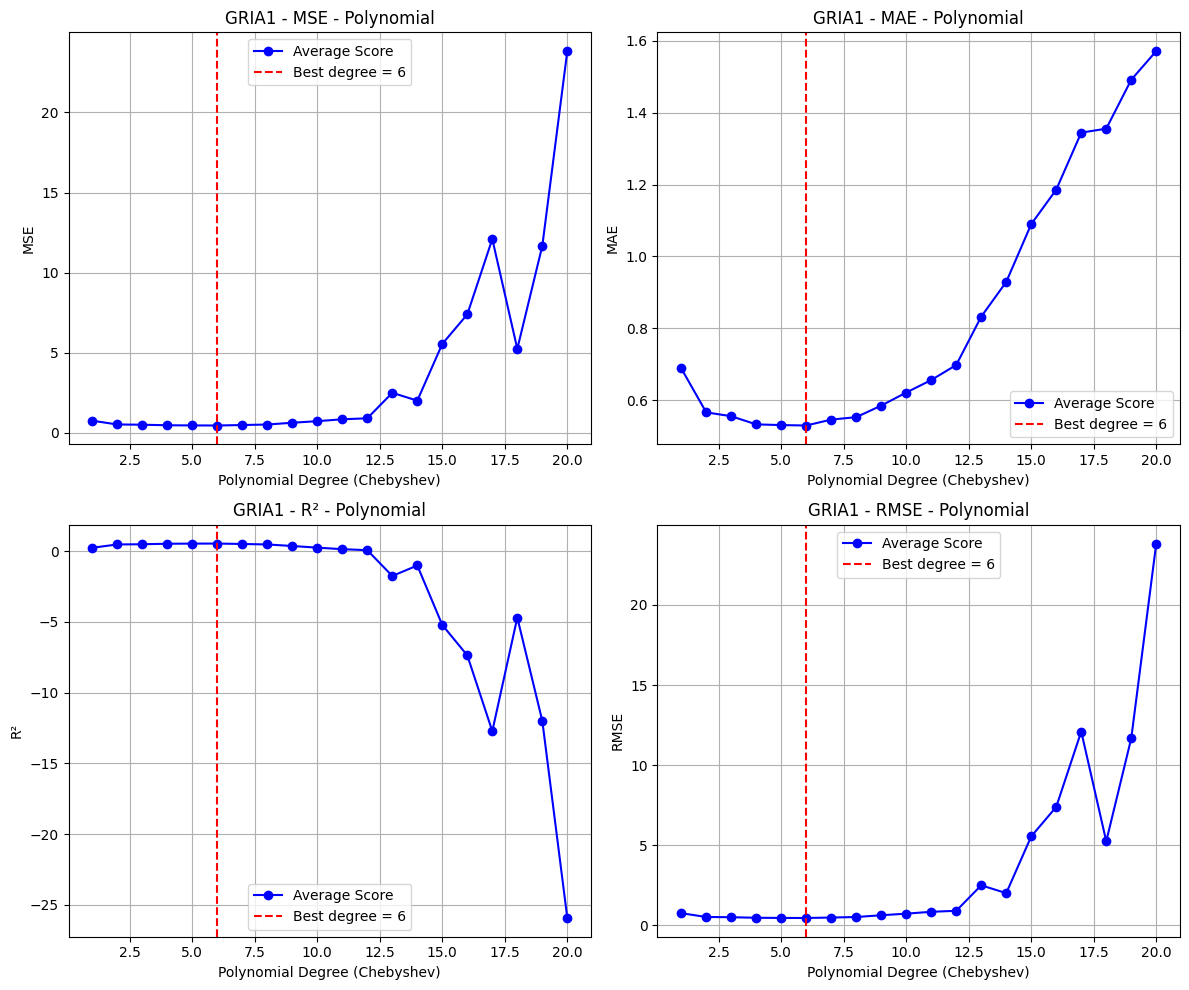

In [20]:
# ----- Cell 2 for GRIA1 -----
# Calculate the average of each degree and draw line charts
# ----------------------------

# Compute average scores across folds for each degree
gria1_mean_metrics = {metric: gria1_results[metric].mean(axis=0) for metric in gria1_results}

# Print average values for each degree
print("GRIA1 - Average Scores by Degree (Chebyshev):")
for metric in gria1_mean_metrics:
    print(f"\n{metric.upper()}:")
    print(gria1_mean_metrics[metric])

# Identify best degree for each metric
gria1_best_degrees = {
    "mse": gria1_mean_metrics["mse"].idxmin(),
    "mae": gria1_mean_metrics["mae"].idxmin(),
    "rmse": gria1_mean_metrics["rmse"].idxmin(),
    "r2": gria1_mean_metrics["r2"].idxmax()
}

# Plotting line plots with best degree marked
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()
titles = ["MSE - Polynomial", "MAE - Polynomial", "R² - Polynomial", "RMSE - Polynomial"]
ylabels = ["MSE", "MAE", "R²", "RMSE"]
metrics_list = ["mse", "mae", "r2", "rmse"]

for i, metric in enumerate(metrics_list):
    degrees = gria1_mean_metrics[metric].index
    values = gria1_mean_metrics[metric].values
    axs[i].plot(degrees, values, marker='o', color='blue', label='Average Score')
    axs[i].axvline(gria1_best_degrees[metric], color="red", linestyle="--", label=f"Best degree = {gria1_best_degrees[metric]}")
    axs[i].set_title(f"GRIA1 - {titles[i]}")
    axs[i].set_xlabel("Polynomial Degree (Chebyshev)")
    axs[i].set_ylabel(ylabels[i])
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


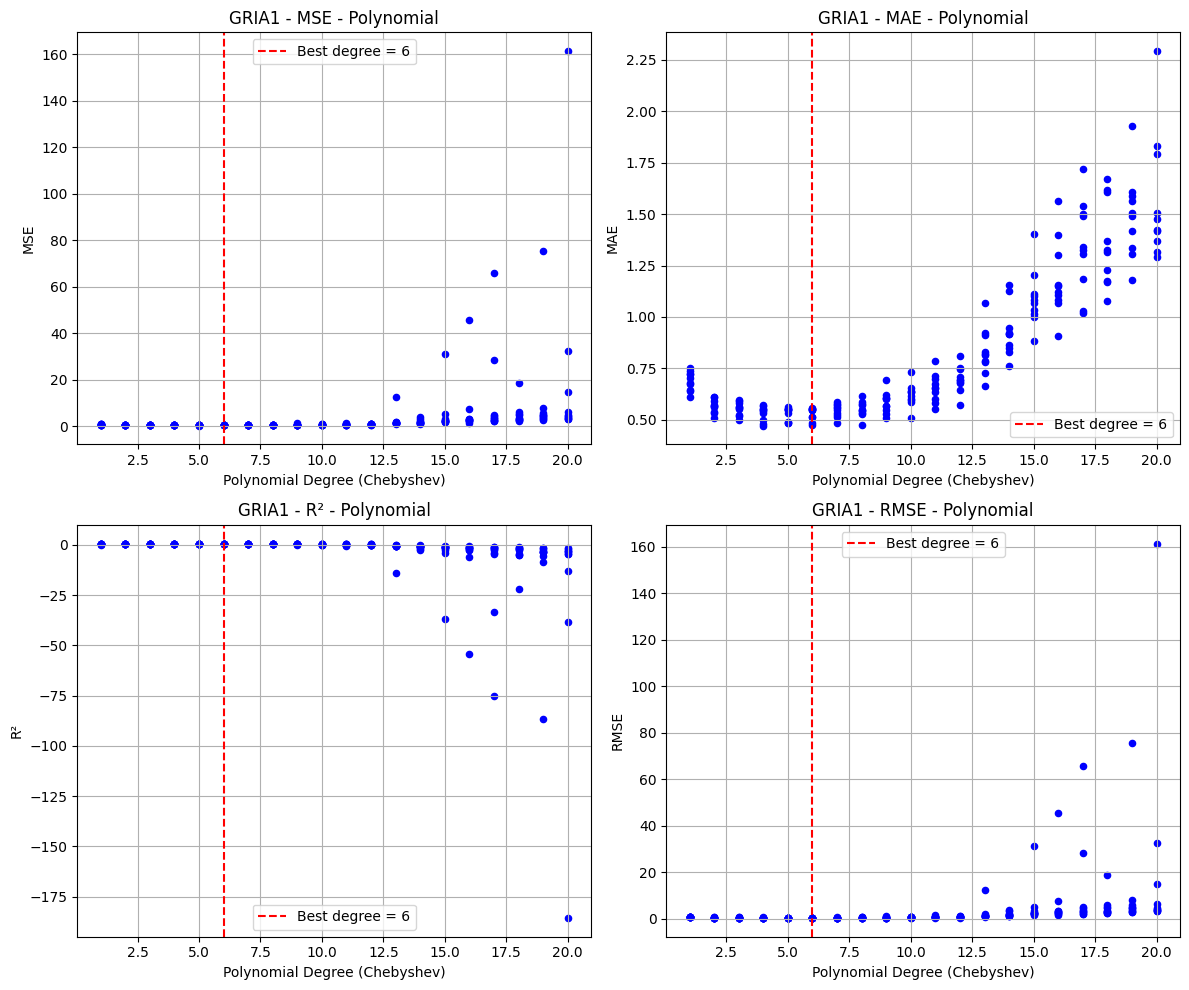

In [21]:
# ----- Cell 3 for GRIA1 -----
# Show per-fold scatter diagram for each metric and best degree line
# ----------------------------

import matplotlib.pyplot as plt

# Plotting all folds' scores (scatter points per fold and degree)
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
axs = axs.ravel()

titles = ["MSE - Polynomial", "MAE - Polynomial", "R² - Polynomial", "RMSE - Polynomial"]
ylabels = ["MSE", "MAE", "R²", "RMSE"]
metrics_list = ["mse", "mae", "r2", "rmse"]

# Compute average values to find best degree per metric
gria1_mean_metrics = {metric: gria1_results[metric].mean(axis=0) for metric in gria1_results}
gria1_best_degrees = {
    "mse": gria1_mean_metrics["mse"].idxmin(),
    "mae": gria1_mean_metrics["mae"].idxmin(),
    "rmse": gria1_mean_metrics["rmse"].idxmin(),
    "r2": gria1_mean_metrics["r2"].idxmax()
}

# Plot each fold’s score as a dot
for i, metric in enumerate(metrics_list):
    for degree in gria1_results[metric].columns:
        axs[i].scatter([degree]*gria1_results[metric].shape[0], gria1_results[metric][degree],
                       color="blue", s=20)
    axs[i].axvline(gria1_best_degrees[metric], color="red", linestyle="--",
                   label=f"Best degree = {gria1_best_degrees[metric]}")
    axs[i].set_title(f"GRIA1 - {titles[i]}")
    axs[i].set_xlabel("Polynomial Degree (Chebyshev)")
    axs[i].set_ylabel(ylabels[i])
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


In [22]:
# ----- Cell 4 for GRIA1 -----
# t-test: degree 2–6 for each metric in gria1_results
# ---------------------------------

from scipy.stats import ttest_rel
import itertools

# Define degree range and metrics
gria1_target_degrees = list(range(2, 7))  # degrees 2 to 6
gria1_metrics_to_test = ["mse", "mae", "rmse", "r2"]

# Container to store t-test results
gria1_ttest_tables = {}

# Perform pairwise t-tests
for metric in gria1_metrics_to_test:
    subset = gria1_results[metric].loc[:, gria1_target_degrees]
    degree_pairs = list(itertools.combinations(subset.columns, 2))
    ttest_results = []

    for d1, d2 in degree_pairs:
        t_stat, p_val = ttest_rel(subset[d1], subset[d2])
        ttest_results.append((d1, d2, p_val))

    df = pd.DataFrame(ttest_results, columns=["Degree 1", "Degree 2", "p-value"])
    df_sorted = df.sort_values("p-value")
    gria1_ttest_tables[metric] = df_sorted

# Display results
for metric in gria1_metrics_to_test:
    print(f"\nGRIA1 - Pairwise t-test on {metric.upper()} (degree 2–6):")
    display(gria1_ttest_tables[metric])



GRIA1 - Pairwise t-test on MSE (degree 2–6):


,Degree 1,Degree 2,p-value
3,2,6,0.000026
1,2,4,0.000063
4,3,4,0.000074
6,3,6,0.000100
2,2,5,0.000127
5,3,5,0.000350
0,2,3,0.013093
8,4,6,0.052782
7,4,5,0.071069
9,5,6,0.464503



GRIA1 - Pairwise t-test on MAE (degree 2–6):


,Degree 1,Degree 2,p-value
1,2,4,0.000017
4,3,4,0.000030
3,2,6,0.000138
0,2,3,0.000326
2,2,5,0.000350
6,3,6,0.001146
5,3,5,0.001492
8,4,6,0.574825
7,4,5,0.646954
9,5,6,0.770225



GRIA1 - Pairwise t-test on RMSE (degree 2–6):


,Degree 1,Degree 2,p-value
3,2,6,0.000026
1,2,4,0.000063
4,3,4,0.000074
6,3,6,0.000100
2,2,5,0.000127
5,3,5,0.000350
0,2,3,0.013093
8,4,6,0.052782
7,4,5,0.071069
9,5,6,0.464503



GRIA1 - Pairwise t-test on R2 (degree 2–6):


,Degree 1,Degree 2,p-value
3,2,6,0.000009
6,3,6,0.000080
1,2,4,0.000092
2,2,5,0.000113
4,3,4,0.000144
5,3,5,0.000348
0,2,3,0.012681
7,4,5,0.066044
8,4,6,0.083366
9,5,6,0.568308


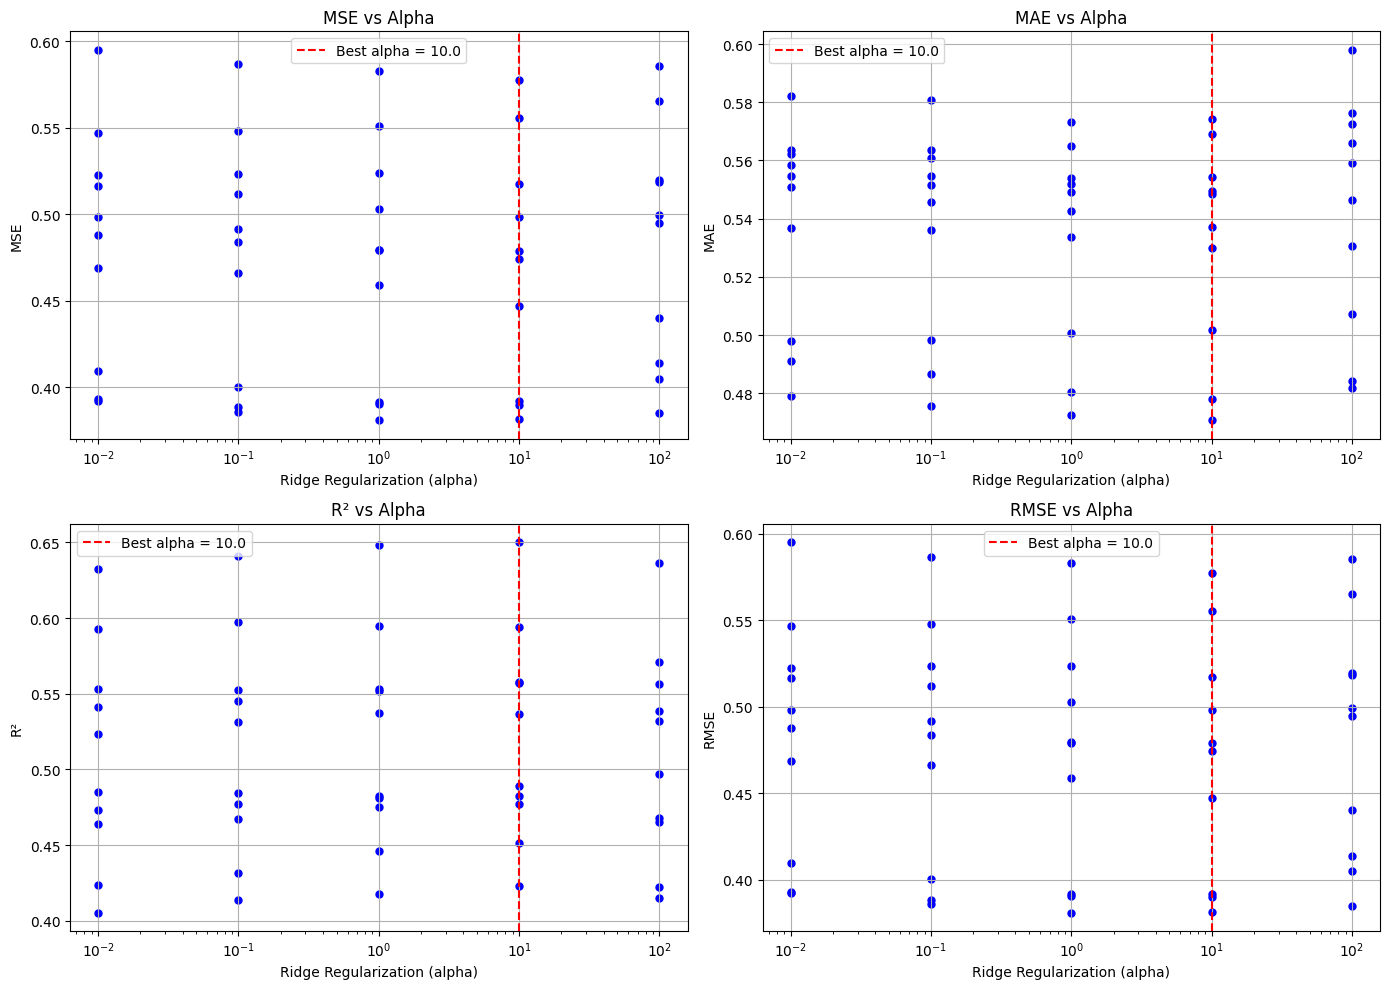

In [31]:
# ----- Cell 6 -----
# Alpha tuning for GRIA1 @ fixed degree = 4, visualize fold-wise scores
# --------------------------------------------------------

alpha_values = [0.01, 0.1, 1.0, 10, 100]
fixed_degree = 4
gria1_alpha_results = {metric: pd.DataFrame(index=range(gria1_num_folds), columns=alpha_values) for metric in gria1_metrics}

# Cross-validation
for alpha in alpha_values:
    for i, (train_idx, test_idx) in enumerate(gria1_kf.split(gria1_coords)):
        train_coords, test_coords = gria1_coords[train_idx], gria1_coords[test_idx]
        train_values, test_values = gria1_values[train_idx], gria1_values[test_idx]
        pred_values = yuanting(train_coords, train_values, test_coords, degree=fixed_degree, alpha=alpha)
        scores = calculate_metrics(pred_values, test_values)
        for metric in gria1_metrics:
            gria1_alpha_results[metric].loc[i, alpha] = scores[metric]

# Ensure numeric types
for metric in gria1_alpha_results:
    gria1_alpha_results[metric] = gria1_alpha_results[metric].astype(float)

# Compute mean values and find best alpha per metric
mean_alpha_metrics = {metric: df.mean(axis=0) for metric, df in gria1_alpha_results.items()}
best_alphas = {
    "mse": mean_alpha_metrics["mse"].idxmin(),
    "mae": mean_alpha_metrics["mae"].idxmin(),
    "rmse": mean_alpha_metrics["rmse"].idxmin(),
    "r2": mean_alpha_metrics["r2"].idxmax(),
}

# Plotting scatter points (per fold) across alpha
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.ravel()
titles = ["MSE vs Alpha", "MAE vs Alpha", "R² vs Alpha", "RMSE vs Alpha"]
ylabels = ["MSE", "MAE", "R²", "RMSE"]
metrics_list = ["mse", "mae", "r2", "rmse"]

for i, metric in enumerate(metrics_list):
    for alpha in alpha_values:
        axs[i].scatter([alpha] * gria1_num_folds, gria1_alpha_results[metric][alpha], color='blue', s=25)
    axs[i].axvline(best_alphas[metric], color='red', linestyle='--', label=f"Best alpha = {best_alphas[metric]}")
    axs[i].set_title(titles[i])
    axs[i].set_xlabel("Ridge Regularization (alpha)")
    axs[i].set_ylabel(ylabels[i])
    axs[i].set_xscale('log')
    axs[i].legend()
    axs[i].grid(True)

plt.tight_layout()
plt.show()


GRIA1 Interpolation Metrics (degree = 6, alpha = 10):
MSE: 0.37611
MAE: 0.47667
RMSE: 0.37611
R2: 0.62323


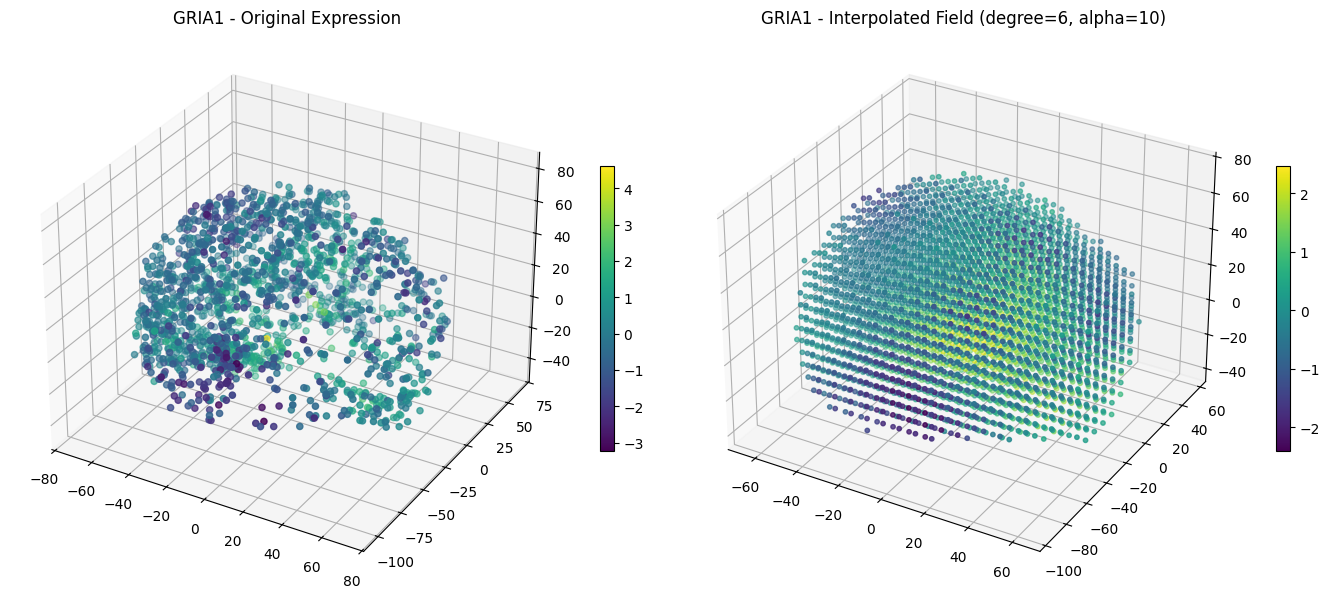

In [32]:
# ----- Cell 5 for GRIA1 -----
# 3D Visualization of original and interpolated GRIA1 expression using degree 6 & alpha=10
# + Show interpolation metrics
# --------------------------------------------

from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from scipy.spatial import Delaunay

# Select best degree and alpha
gria1_best_degree = 6
gria1_best_alpha = 10  # New parameter

# Use all points for training
train_coords = gria1_coords
train_values = gria1_values

# Generate dense 3D grid within the bounding box
grid_size = 20
x = np.linspace(train_coords[:, 0].min(), train_coords[:, 0].max(), grid_size)
y = np.linspace(train_coords[:, 1].min(), train_coords[:, 1].max(), grid_size)
z = np.linspace(train_coords[:, 2].min(), train_coords[:, 2].max(), grid_size)
xx, yy, zz = np.meshgrid(x, y, z)
grid_coords = np.vstack([xx.ravel(), yy.ravel(), zz.ravel()]).T

# Use convex hull mask to keep only inside-brain grid points
hull = Delaunay(train_coords)
mask = hull.find_simplex(grid_coords) >= 0
masked_grid = grid_coords[mask]

# Interpolate values within the brain region using alpha=10
interpolated_values = yuanting(train_coords, train_values, masked_grid,
                               degree=gria1_best_degree, alpha=gria1_best_alpha)

# Predict back on training set for metric evaluation (no held-out set)
reconstructed_train_values = yuanting(train_coords, train_values, train_coords,
                                      degree=gria1_best_degree, alpha=gria1_best_alpha)
gria1_interp_metrics = calculate_metrics(reconstructed_train_values, train_values)

# Output evaluation metrics
print(f"GRIA1 Interpolation Metrics (degree = {gria1_best_degree}, alpha = {gria1_best_alpha}):")
for k, v in gria1_interp_metrics.items():
    print(f"{k.upper()}: {v:.5f}")

# === Plot original data ===
fig = plt.figure(figsize=(14, 6))

ax1 = fig.add_subplot(121, projection='3d')
sc1 = ax1.scatter(train_coords[:, 0], train_coords[:, 1], train_coords[:, 2],
                  c=train_values, cmap='viridis', s=20)
ax1.set_title("GRIA1 - Original Expression")
fig.colorbar(sc1, ax=ax1, shrink=0.5)

# === Plot interpolated brain-only region ===
ax2 = fig.add_subplot(122, projection='3d')
sc2 = ax2.scatter(masked_grid[:, 0], masked_grid[:, 1], masked_grid[:, 2],
                  c=interpolated_values, cmap='viridis', s=10)
ax2.set_title(f"GRIA1 - Interpolated Field (degree={gria1_best_degree}, alpha={gria1_best_alpha})")
fig.colorbar(sc2, ax=ax2, shrink=0.5)

plt.tight_layout()
plt.show()
